In [2]:
import pandas as pd

In [3]:
data= pd.read_csv("../data/raw/startup_funding.csv")
data

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN
...,...,...,...,...,...,...,...,...,...,...
3039,3040,29/01/2015,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,"45,00,000",NaN
3040,3041,29/01/2015,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,"8,25,000",Govt backed VC Fund
3041,3042,30/01/2015,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000",NaN
3042,3043,30/01/2015,Simplotel,NaN,NaN,NaN,MakeMyTrip,Private Equity,NaN,"Strategic Funding, Minority stake"


In [4]:
print("Data Size: ",data.size)

print ("Data Shape (rows, columns): ",data.shape)

print("Data Columns:  ",data.columns)

print("Data types: ", data.dtypes)


Data Size:  30440
Data Shape (rows, columns):  (3044, 10)
Data Columns:   Index(['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical',
       'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType',
       'Amount in USD', 'Remarks'],
      dtype='str')
Data types:  Sr No                int64
Date dd/mm/yyyy        str
Startup Name           str
Industry Vertical      str
SubVertical            str
City  Location         str
Investors Name         str
InvestmentnType        str
Amount in USD          str
Remarks                str
dtype: object


In [5]:
# Basic info of dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Sr No              3044 non-null   int64
 1   Date dd/mm/yyyy    3044 non-null   str  
 2   Startup Name       3044 non-null   str  
 3   Industry Vertical  2873 non-null   str  
 4   SubVertical        2108 non-null   str  
 5   City  Location     2864 non-null   str  
 6   Investors Name     3020 non-null   str  
 7   InvestmentnType    3040 non-null   str  
 8   Amount in USD      2084 non-null   str  
 9   Remarks            419 non-null    str  
dtypes: int64(1), str(9)
memory usage: 237.9 KB


In [6]:
data["Amount in USD"].value_counts().head(20)

Amount in USD
10,00,000      165
5,00,000       108
20,00,000       69
30,00,000       66
50,00,000       66
1,00,00,000     60
1,00,000        57
1,50,000        45
2,00,000        44
2,50,000        41
60,00,000       40
1,50,00,000     39
15,00,000       37
40,00,000       35
3,00,000        31
25,00,000       25
5,00,00,000     24
6,00,000        23
2,00,00,000     21
4,00,000        21
Name: count, dtype: int64

In [7]:
data["Amount in USD"].tail(20)
data["Amount in USD"].value_counts()

Amount in USD
10,00,000      165
5,00,000       108
20,00,000       69
30,00,000       66
50,00,000       66
              ... 
1,35,000         1
2,85,000         1
30,768           1
1,47,50,000      1
32,50,000        1
Name: count, Length: 471, dtype: int64

In [8]:
data["Amount in USD"].value_counts()

Amount in USD
10,00,000      165
5,00,000       108
20,00,000       69
30,00,000       66
50,00,000       66
              ... 
1,35,000         1
2,85,000         1
30,768           1
1,47,50,000      1
32,50,000        1
Name: count, Length: 471, dtype: int64

In [9]:
data["Amount in USD"].value_counts().loc[["undisclosed", "unknown"]]

Amount in USD
undisclosed    3
unknown        1
Name: count, dtype: int64

In [10]:
pd.to_numeric("10,00,000", errors="coerce")

np.float64(nan)

In [11]:
amount_test = pd.to_numeric(
    data["Amount in USD"].str.replace(",", ""),
    errors="coerce"
)

amount_test

0       200000000.0
1         8048394.0
2        18358860.0
3         3000000.0
4         1800000.0
           ...     
3039      4500000.0
3040       825000.0
3041      1500000.0
3042            NaN
3043       140000.0
Name: Amount in USD, Length: 3044, dtype: float64

In [12]:
amount_test.isna().sum()

np.int64(979)

In [13]:
data.loc[
    (amount_test.isna()) & (data["Amount in USD"].notna()),
    "Amount in USD"
]

20               undisclosed
34                   unknown
58               Undisclosed
89               undisclosed
91               undisclosed
109              14,342,000+
112              Undisclosed
139              Undisclosed
2602    \\xc2\\xa020,000,000
2603    \\xc2\\xa016,200,000
2604           \\xc2\\xa0N/A
2605           \\xc2\\xa0N/A
2606       \\xc2\\xa0600,000
2607       \\xc2\\xa0685,000
2608    \\xc2\\xa019,350,000
2609     \\xc2\\xa05,000,000
2610    \\xc2\\xa010,000,000
2611           \\xc2\\xa0N/A
2613           \\xc2\\xa0N/A
Name: Amount in USD, dtype: str

In [14]:
problematic_rows = (amount_test.isna()) & (data["Amount in USD"].notna())

data.loc[
    problematic_rows,
    ["Startup Name", "Amount in USD", "Remarks"]
]

,Startup Name,Amount in USD,Remarks
20,Burger Singh,undisclosed,NaN
34,The Man Company,unknown,NaN
58,Mishry Reviews,Undisclosed,NaN
89,Ola Electric,undisclosed,NaN
91,StyleDotMe,undisclosed,NaN
109,KrazyBee,"14,342,000+",NaN
112,FleetX,Undisclosed,NaN
139,Skillbox,Undisclosed,NaN
2602,\\xc2\\xa0News in shorts,"\\xc2\\xa020,000,000",\\xc2\\xa0Series B
2603,\\xc2\\xa0Bluestone,"\\xc2\\xa016,200,000",NaN


In [15]:
data.loc[
    data["Amount in USD"].str.contains(r"\+", na=False),
    "Amount in USD"
]

109    14,342,000+
Name: Amount in USD, dtype: str

In [16]:
cleaned_data = data.copy()

In [17]:
cleaned_data["amount_is_lower_bound"] = cleaned_data["Amount in USD"].str.contains(
    r"\+",
    na=False
)

In [18]:
cleaned_data["amount_is_lower_bound"].value_counts()


amount_is_lower_bound
False    3043
True        1
Name: count, dtype: int64

In [19]:
cleaned_data["amount_cleaned_text"] = cleaned_data["Amount in USD"].str.strip()

In [20]:
cleaned_data.loc[
    problematic_rows,
    ["Amount in USD", "amount_cleaned_text"]
]

,Amount in USD,amount_cleaned_text
20,undisclosed,undisclosed
34,unknown,unknown
58,Undisclosed,Undisclosed
89,undisclosed,undisclosed
91,undisclosed,undisclosed
109,"14,342,000+","14,342,000+"
112,Undisclosed,Undisclosed
139,Undisclosed,Undisclosed
2602,"\\xc2\\xa020,000,000","\\xc2\\xa020,000,000"
2603,"\\xc2\\xa016,200,000","\\xc2\\xa016,200,000"


In [21]:
repr(cleaned_data.loc[2602, "Amount in USD"])

"'\\\\\\\\xc2\\\\\\\\xa020,000,000'"

In [22]:
print(cleaned_data.loc[2602, "Amount in USD"])

\\xc2\\xa020,000,000


In [23]:
cleaned_data["amount_cleaned_text"] = (
    cleaned_data["amount_cleaned_text"]
    .str.replace(r"\\xc2\\xa0", "", regex=True)
)

In [24]:
cleaned_data.loc[
    problematic_rows,
    ["Amount in USD", "amount_cleaned_text"]
]

,Amount in USD,amount_cleaned_text
20,undisclosed,undisclosed
34,unknown,unknown
58,Undisclosed,Undisclosed
89,undisclosed,undisclosed
91,undisclosed,undisclosed
109,"14,342,000+","14,342,000+"
112,Undisclosed,Undisclosed
139,Undisclosed,Undisclosed
2602,"\\xc2\\xa020,000,000","\\xc2\\xa020,000,000"
2603,"\\xc2\\xa016,200,000","\\xc2\\xa016,200,000"


In [25]:
repr(cleaned_data.loc[2602, "amount_cleaned_text"])

"'\\\\\\\\xc2\\\\\\\\xa020,000,000'"

In [26]:
len(cleaned_data.loc[2602, "amount_cleaned_text"])

20

In [27]:
cleaned_data["amount_cleaned_text"] = (
    cleaned_data["amount_cleaned_text"]
    .str.replace(r"\\\\xc2\\\\xa0", "", regex=True)
)

In [28]:
repr(cleaned_data.loc[2602, "amount_cleaned_text"])

"'20,000,000'"

In [29]:
cleaned_data.loc[
    problematic_rows,
    ["Amount in USD", "amount_cleaned_text"]
]

,Amount in USD,amount_cleaned_text
20,undisclosed,undisclosed
34,unknown,unknown
58,Undisclosed,Undisclosed
89,undisclosed,undisclosed
91,undisclosed,undisclosed
109,"14,342,000+","14,342,000+"
112,Undisclosed,Undisclosed
139,Undisclosed,Undisclosed
2602,"\\xc2\\xa020,000,000","20,000,000"
2603,"\\xc2\\xa016,200,000","16,200,000"


In [30]:
cleaned_data["amount_cleaned_text"] = (
    cleaned_data["amount_cleaned_text"].str.lower()
)

In [31]:
cleaned_data.loc[
    problematic_rows,
    ["Amount in USD", "amount_cleaned_text"]
]

,Amount in USD,amount_cleaned_text
20,undisclosed,undisclosed
34,unknown,unknown
58,Undisclosed,undisclosed
89,undisclosed,undisclosed
91,undisclosed,undisclosed
109,"14,342,000+","14,342,000+"
112,Undisclosed,undisclosed
139,Undisclosed,undisclosed
2602,"\\xc2\\xa020,000,000","20,000,000"
2603,"\\xc2\\xa016,200,000","16,200,000"


In [32]:

import numpy as np

cleaned_data["amount_cleaned_text"] = cleaned_data["amount_cleaned_text"].replace({
    "undisclosed": np.nan,
    "unknown": np.nan,
    "n/a": np.nan
})

In [33]:
cleaned_data["amount_cleaned_text"].value_counts(dropna=False).head(20)

amount_cleaned_text
NaN            971
10,00,000      165
5,00,000       108
20,00,000       69
30,00,000       66
50,00,000       66
1,00,00,000     60
1,00,000        57
1,50,000        45
2,00,000        44
2,50,000        41
60,00,000       40
1,50,00,000     39
15,00,000       37
40,00,000       35
3,00,000        31
25,00,000       25
5,00,00,000     24
6,00,000        23
2,00,00,000     21
Name: count, dtype: int64

In [34]:
cleaned_data["amount_cleaned_text"] = (
    cleaned_data["amount_cleaned_text"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

In [35]:
cleaned_data["funding_amount_usd"] = pd.to_numeric(
    cleaned_data["amount_cleaned_text"],
    errors="coerce"
)

In [36]:
cleaned_data[
    ["Amount in USD", "amount_cleaned_text", "funding_amount_usd", "amount_is_lower_bound"]
].head(20)

,Amount in USD,amount_cleaned_text,funding_amount_usd,amount_is_lower_bound
0,"20,00,00,000",200000000,200000000.0,False
1,"80,48,394",8048394,8048394.0,False
2,"1,83,58,860",18358860,18358860.0,False
3,"30,00,000",3000000,3000000.0,False
4,"18,00,000",1800000,1800000.0,False
5,"90,00,000",9000000,9000000.0,False
6,"15,00,00,000",150000000,150000000.0,False
7,"60,00,000",6000000,6000000.0,False
8,"7,00,00,000",70000000,70000000.0,False
9,"5,00,00,000",50000000,50000000.0,False


In [37]:
cleaned_data["funding_amount_usd"].dtype

dtype('float64')

In [38]:
cleaned_data["funding_amount_usd"].isna().sum()


np.int64(971)

In [39]:
cleaned_data.loc[
    cleaned_data["funding_amount_usd"].isna() &
    data["Amount in USD"].notna(),
    ["Startup Name", "Amount in USD", "funding_amount_usd"]
]

,Startup Name,Amount in USD,funding_amount_usd
20,Burger Singh,undisclosed,NaN
34,The Man Company,unknown,NaN
58,Mishry Reviews,Undisclosed,NaN
89,Ola Electric,undisclosed,NaN
91,StyleDotMe,undisclosed,NaN
112,FleetX,Undisclosed,NaN
139,Skillbox,Undisclosed,NaN
2604,\\xc2\\xa0Shopsity,\\xc2\\xa0N/A,NaN
2605,\\xc2\\xa0Notesgen,\\xc2\\xa0N/A,NaN
2611,\\xc2\\xa0Satvacart,\\xc2\\xa0N/A,NaN


In [40]:
cleaned_data

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks,amount_is_lower_bound,amount_cleaned_text,funding_amount_usd
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN,False,200000000,200000000.0
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN,False,8048394,8048394.0
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN,False,18358860,18358860.0
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN,False,3000000,3000000.0
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN,False,1800000,1800000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3039,3040,29/01/2015,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,"45,00,000",NaN,False,4500000,4500000.0
3040,3041,29/01/2015,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,"8,25,000",Govt backed VC Fund,False,825000,825000.0
3041,3042,30/01/2015,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000",NaN,False,1500000,1500000.0
3042,3043,30/01/2015,Simplotel,NaN,NaN,NaN,MakeMyTrip,Private Equity,NaN,"Strategic Funding, Minority stake",False,NaN,NaN


In [41]:
cleaned_data["Date dd/mm/yyyy"]
cleaned_data["Date dd/mm/yyyy"].head(20)

0     09/01/2020
1     13/01/2020
2     09/01/2020
3     02/01/2020
4     02/01/2020
5     13/01/2020
6     10/01/2020
7     12/12/2019
8     06/12/2019
9     03/12/2019
10    13/12/2019
11    17/12/2019
12    16/12/2019
13    16/12/2019
14    14/12/2019
15    11/12/2019
16    20/12/2019
17    13/11/2019
18    14/11/2019
19    13/11/2019
Name: Date dd/mm/yyyy, dtype: str

In [42]:
cleaned_data["Date dd/mm/yyyy"].isna().sum()


np.int64(0)

In [43]:
cleaned_data["Date dd/mm/yyyy"].nunique()

1035

In [44]:
cleaned_data["Date dd/mm/yyyy"].head(20)

0     09/01/2020
1     13/01/2020
2     09/01/2020
3     02/01/2020
4     02/01/2020
5     13/01/2020
6     10/01/2020
7     12/12/2019
8     06/12/2019
9     03/12/2019
10    13/12/2019
11    17/12/2019
12    16/12/2019
13    16/12/2019
14    14/12/2019
15    11/12/2019
16    20/12/2019
17    13/11/2019
18    14/11/2019
19    13/11/2019
Name: Date dd/mm/yyyy, dtype: str

In [45]:
cleaned_data["Date dd/mm/yyyy"].tail(20)


3024     20/01/2015
3025     21/01/2015
3026     21/01/2015
3027     21/05/2015
3028     21/05/2015
3029    22/01//2015
3030     22/01/2015
3031     22/01/2015
3032     22/01/2015
3033     22/01/2015
3034     24/01/2015
3035     24/01/2015
3036     25/01/2015
3037     27/01/2015
3038     28/01/2015
3039     29/01/2015
3040     29/01/2015
3041     30/01/2015
3042     30/01/2015
3043     31/01/2015
Name: Date dd/mm/yyyy, dtype: str

In [46]:
date_test = pd.to_datetime(
    cleaned_data["Date dd/mm/yyyy"],
    format="%d/%m/%Y",
    errors="coerce"
)

In [47]:
cleaned_data.loc[
    date_test.isna(),
    "Date dd/mm/yyyy"
]

192               05/072018
2571              01/07/015
2606    \\xc2\\xa010/7/2015
2775             12/05.2015
2776             12/05.2015
2831             13/04.2015
3011             15/01.2015
3029            22/01//2015
Name: Date dd/mm/yyyy, dtype: str

In [48]:
cleaned_data["date_cleaned_text"] = cleaned_data["Date dd/mm/yyyy"].copy()

In [49]:
cleaned_data["date_cleaned_text"] = (
    cleaned_data["date_cleaned_text"]
    .str.replace(r"\\xc2\\xa0", "", regex=True)
    .str.replace(".", "/", regex=False)
    .str.replace("//", "/", regex=False)
)

In [50]:
cleaned_data["date_cleaned_text"] = (
    cleaned_data["date_cleaned_text"]
    .str.replace("22/01//2015", "22/01/2015", regex=False)
)

In [51]:
cleaned_data.loc[
    [192, 2571, 2606, 2775, 2776, 2831, 3011, 3029],
    ["Date dd/mm/yyyy", "date_cleaned_text"]
]

,Date dd/mm/yyyy,date_cleaned_text
192,05/072018,05/072018
2571,01/07/015,01/07/015
2606,\\xc2\\xa010/7/2015,\\xc2\\xa010/7/2015
2775,12/05.2015,12/05/2015
2776,12/05.2015,12/05/2015
2831,13/04.2015,13/04/2015
3011,15/01.2015,15/01/2015
3029,22/01//2015,22/01/2015


In [52]:
print(repr(cleaned_data.loc[192, "date_cleaned_text"]))
print(repr(cleaned_data.loc[2571, "date_cleaned_text"]))
print(repr(cleaned_data.loc[2606, "date_cleaned_text"]))

'05/072018'
'01/07/015'
'\\\\xc2\\\\xa010/7/2015'


In [53]:
print(len(cleaned_data.loc[192, "date_cleaned_text"]))
print(len(cleaned_data.loc[2571, "date_cleaned_text"]))
print(len(cleaned_data.loc[2606, "date_cleaned_text"]))

9
9
19


In [54]:
cleaned_data["date_cleaned_text"] = cleaned_data["Date dd/mm/yyyy"].copy()

cleaned_data["date_cleaned_text"] = (
    cleaned_data["date_cleaned_text"]
    .str.replace(r"\\\\xc2\\\\xa0", "", regex=True)
    .str.replace("05/072018", "05/07/2018", regex=False)
    .str.replace("01/07/015", "01/07/2015", regex=False)
    .str.replace("12/05.2015", "12/05/2015", regex=False)
    .str.replace("13/04.2015", "13/04/2015", regex=False)
    .str.replace("15/01.2015", "15/01/2015", regex=False)
    .str.replace("22/01//2015", "22/01/2015", regex=False)
)

In [55]:
cleaned_data.loc[
    [192, 2571, 2606, 2775, 2776, 2831, 3011, 3029],
    ["Date dd/mm/yyyy", "date_cleaned_text"]
]

,Date dd/mm/yyyy,date_cleaned_text
192,05/072018,05/07/2018
2571,01/07/015,01/07/2015
2606,\\xc2\\xa010/7/2015,10/7/2015
2775,12/05.2015,12/05/2015
2776,12/05.2015,12/05/2015
2831,13/04.2015,13/04/2015
3011,15/01.2015,15/01/2015
3029,22/01//2015,22/01/2015


In [56]:
cleaned_data["funding_date"] = pd.to_datetime(
    cleaned_data["date_cleaned_text"],
    format="%d/%m/%Y",
    errors="coerce"
)

In [57]:
cleaned_data["funding_date"].dtype

dtype('<M8[us]')

In [58]:
cleaned_data["funding_date"].isna().sum()

np.int64(0)

In [59]:
cleaned_data

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks,amount_is_lower_bound,amount_cleaned_text,funding_amount_usd,date_cleaned_text,funding_date
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN,False,200000000,200000000.0,09/01/2020,2020-01-09
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN,False,8048394,8048394.0,13/01/2020,2020-01-13
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN,False,18358860,18358860.0,09/01/2020,2020-01-09
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN,False,3000000,3000000.0,02/01/2020,2020-01-02
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN,False,1800000,1800000.0,02/01/2020,2020-01-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3039,3040,29/01/2015,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,"45,00,000",NaN,False,4500000,4500000.0,29/01/2015,2015-01-29
3040,3041,29/01/2015,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,"8,25,000",Govt backed VC Fund,False,825000,825000.0,29/01/2015,2015-01-29
3041,3042,30/01/2015,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000",NaN,False,1500000,1500000.0,30/01/2015,2015-01-30
3042,3043,30/01/2015,Simplotel,NaN,NaN,NaN,MakeMyTrip,Private Equity,NaN,"Strategic Funding, Minority stake",False,NaN,NaN,30/01/2015,2015-01-30


In [60]:
cleaned_data["Industry Vertical"].isna().sum()

np.int64(171)

In [61]:
cleaned_data["Industry Vertical"].nunique()

821

In [62]:
cleaned_data["Industry Vertical"].value_counts(dropna=False).head(30)


Industry Vertical
Consumer Internet            941
Technology                   478
eCommerce                    186
NaN                          171
Healthcare                    70
Finance                       62
ECommerce                     61
Logistics                     32
E-Commerce                    29
Education                     24
Food & Beverage               23
Ed-Tech                       14
E-commerce                    12
FinTech                        9
Ecommerce                      8
IT                             8
Food and Beverage              6
Real Estate                    6
Fin-Tech                       6
Others                         6
Health and Wellness            5
Logistics Tech                 5
Online Education Platform      5
Online Food Delivery           5
Transportation                 4
Transport                      4
SaaS                           3
Information Technology         3
EdTech                         3
Services                 

In [63]:
cleaned_data["industry_cleaned"] = (
    cleaned_data["Industry Vertical"]
    .str.strip()
    .str.lower()
)

In [64]:
cleaned_data["industry_cleaned"].value_counts(dropna=False).head(30)

industry_cleaned
consumer internet               942
technology                      478
ecommerce                       258
NaN                             171
healthcare                       71
finance                          62
e-commerce                       41
logistics                        32
education                        24
food & beverage                  23
ed-tech                          15
fintech                          10
it                                8
health and wellness               6
food and beverage                 6
real estate                       6
fin-tech                          6
others                            6
edtech                            5
logistics tech                    5
online education platform         5
online food delivery              5
transportation                    4
saas                              4
transport                         4
food delivery platform            4
hyperlocal handyman services      4
information

In [65]:
cleaned_data["industry_standardized"] = (
    cleaned_data["industry_cleaned"]
    .str.replace("-", "", regex=False)
)

In [66]:
cleaned_data["industry_standardized"].value_counts(dropna=False).head(30)


industry_standardized
consumer internet               942
technology                      478
ecommerce                       299
NaN                             171
healthcare                       71
finance                          62
logistics                        32
education                        24
food & beverage                  23
edtech                           20
fintech                          16
it                                8
health and wellness               6
food and beverage                 6
real estate                       6
others                            6
logistics tech                    5
online education platform         5
online food delivery              5
transportation                    4
saas                              4
transport                         4
food delivery platform            4
hyperlocal handyman services      4
information technology            3
services                          3
automobile                        3
social

In [67]:
cleaned_data["SubVertical"].value_counts(dropna=False).head(30)

SubVertical
NaN                                              936
Online Lending Platform                           11
Online Pharmacy                                   10
Food Delivery Platform                             8
Education                                          5
Online Education Platform                          5
Online Lending                                     5
Online Learning Platform                           5
Online lending platform                            5
Non-Banking Financial Company                      4
Online Food Delivery                               4
E-learning                                         3
Online Food Delivery Platform                      3
Logistics                                          3
Online Marketplace                                 3
SaaS                                               3
Agri-tech                                          3
Online Insurance Platform                          3
Online Insurance Aggregator       

In [68]:
cleaned_data["SubVertical"].nunique()


1942

In [69]:
cleaned_data.loc[
    cleaned_data["industry_standardized"] == "consumer internet",
    "SubVertical"
].value_counts(dropna=False).head(30)

SubVertical
Food Delivery Platform                           8
Online Learning Platform                         5
Online lending platform                          5
Online Lending Platform                          4
Online Insurance Platform                        3
Online Insurance Aggregator                      3
Fitness Mobile App                               3
Online Home Rental Marketplace                   2
Online Food Delivery                             2
Online Insurance Selling Platform                2
P2P Lending Platform                             2
Beauty e-tailer                                  2
Online Travel Marketplace                        2
Online Pharmacy Store                            2
Health Service Aggregator Platform               2
Online loan platform                             2
Online platform for Higher Education Services    2
App based cab hailing services                   2
Online insurance policy aggregator               2
Online peer-to-peer

In [70]:
industry_counts = (
    cleaned_data["industry_standardized"]
    .value_counts(dropna=False)
)

industry_counts[industry_counts >= 2]

industry_standardized
consumer internet                   942
technology                          478
ecommerce                           299
NaN                                 171
healthcare                           71
                                   ... 
online education marketplace          2
hyperlocal services marketplace       2
customer engagement platform          2
digital / mobile wallet               2
hyperlocal online/mobile grocery      2
Name: count, Length: 81, dtype: int64

In [71]:
cleaned_data["industry_standardized"] = (
    cleaned_data["industry_standardized"]
    .replace({
        "food and beverage": "food & beverage"
    })
)

In [72]:
cleaned_data["industry_standardized"].value_counts().head(25)

industry_standardized
consumer internet               942
technology                      478
ecommerce                       299
healthcare                       71
finance                          62
logistics                        32
food & beverage                  29
education                        24
edtech                           20
fintech                          16
it                                8
health and wellness               6
real estate                       6
others                            6
logistics tech                    5
online education platform         5
online food delivery              5
transportation                    4
saas                              4
transport                         4
food delivery platform            4
hyperlocal handyman services      4
information technology            3
services                          3
automobile                        3
Name: count, dtype: int64

In [73]:
cleaned_data["City  Location"].isna().sum()

np.int64(180)

In [74]:
cleaned_data["City  Location"].nunique()

112

In [75]:
cleaned_data["City  Location"].value_counts(dropna=False).head(30)

City  Location
Bangalore              700
Mumbai                 567
New Delhi              421
Gurgaon                287
NaN                    180
Bengaluru              141
Pune                   105
Hyderabad               99
Chennai                 97
Noida                   92
Gurugram                50
Ahmedabad               38
Delhi                   34
Jaipur                  30
Kolkata                 21
Indore                  13
Chandigarh              11
Goa                     10
Vadodara                10
Singapore                8
Coimbatore               5
Kanpur                   4
Pune / US                4
\\xc2\\xa0Gurgaon        4
Faridabad                3
Bhopal                   3
Nagpur                   3
\\xc2\\xa0New Delhi      3
San Francisco            2
Kormangala               2
Name: count, dtype: int64

In [76]:
cleaned_data["city_cleaned"] = cleaned_data["City  Location"].copy()

In [77]:
cleaned_data["city_cleaned"] = (
    cleaned_data["city_cleaned"]
    .str.replace(r"\\\\xc2\\\\xa0", "", regex=True)
    .str.strip()
)

In [78]:
cleaned_data["city_cleaned"].value_counts(dropna=False).head(30)

city_cleaned
Bangalore           701
Mumbai              568
New Delhi           424
Gurgaon             291
NaN                 180
Bengaluru           141
Pune                105
Hyderabad            99
Chennai              97
Noida                93
Gurugram             50
Ahmedabad            38
Delhi                34
Jaipur               30
Kolkata              21
Indore               13
Chandigarh           11
Goa                  10
Vadodara             10
Singapore             8
Coimbatore            5
Kanpur                4
Pune / US             4
Faridabad             3
Bhopal                3
Nagpur                3
San Francisco         2
Kormangala            2
Mumbai/Bengaluru      2
India/US              2
Name: count, dtype: int64

In [79]:
cleaned_data["city_cleaned"].value_counts(dropna=False).head(30)

city_cleaned
Bangalore           701
Mumbai              568
New Delhi           424
Gurgaon             291
NaN                 180
Bengaluru           141
Pune                105
Hyderabad            99
Chennai              97
Noida                93
Gurugram             50
Ahmedabad            38
Delhi                34
Jaipur               30
Kolkata              21
Indore               13
Chandigarh           11
Goa                  10
Vadodara             10
Singapore             8
Coimbatore            5
Kanpur                4
Pune / US             4
Faridabad             3
Bhopal                3
Nagpur                3
San Francisco         2
Kormangala            2
Mumbai/Bengaluru      2
India/US              2
Name: count, dtype: int64

In [80]:
cleaned_data["city_cleaned"] = cleaned_data["city_cleaned"].replace({
    "Bangalore": "Bengaluru",
    "Gurgaon": "Gurugram"
})

In [81]:
cleaned_data["city_cleaned"].value_counts(dropna=False).head(20)

city_cleaned
Bengaluru     842
Mumbai        568
New Delhi     424
Gurugram      341
NaN           180
Pune          105
Hyderabad      99
Chennai        97
Noida          93
Ahmedabad      38
Delhi          34
Jaipur         30
Kolkata        21
Indore         13
Chandigarh     11
Goa            10
Vadodara       10
Singapore       8
Coimbatore      5
Kanpur          4
Name: count, dtype: int64

In [82]:
cleaned_data.loc[
    cleaned_data["city_cleaned"].notna() &
    (
        cleaned_data["city_cleaned"].str.contains(
            "/", regex=False
        ) |
        cleaned_data["city_cleaned"].str.lower().eq("kormangala")
    ),
    ["Startup Name", "city_cleaned"]
]

,Startup Name,city_cleaned
29,Vogo Automotive,Kormangala
64,Ola Cabs,Kormangala
88,Leegality,Mumbai/Bengaluru
113,Zilingo,India/Singapore
117,Vyome Therapeutics Inc.,India/US
140,Signzy,Mumbai/Bengaluru
141,Engineer.ai,India/US
1350,Zilingo,Bangalore/ Bangkok
1740,Dil Mil,SFO / Bangalore
1824,Skedool,Seattle / Bangalore


In [83]:
cleaned_data["location_type"] = "single_location"

cleaned_data.loc[
    cleaned_data["city_cleaned"].str.contains("/", regex=False, na=False),
    "location_type"
] = "multiple_locations"

cleaned_data.loc[
    cleaned_data["city_cleaned"].str.lower().eq("kormangala"),
    "city_cleaned"
] = "Bengaluru"

In [84]:
cleaned_data["location_type"] == "single_location"

0       True
1       True
2       True
3       True
4       True
        ... 
3039    True
3040    True
3041    True
3042    True
3043    True
Name: location_type, Length: 3044, dtype: bool

In [85]:
cleaned_data["location_type"].value_counts()

location_type
single_location       3006
multiple_locations      38
Name: count, dtype: int64

In [86]:
cleaned_data[
    cleaned_data["location_type"] == "multiple_locations"
]["city_cleaned"].value_counts()

city_cleaned
Pune / US                 4
Mumbai/Bengaluru          2
India/US                  2
Bangalore/ Bangkok        2
Bangalore / SFO           2
New Delhi / US            2
India/Singapore           1
SFO / Bangalore           1
Seattle / Bangalore       1
Pune/Seattle              1
Pune / Dubai              1
Mumbai / UK               1
Hyderabad/USA             1
Bangalore / Palo Alto     1
Mumbai / NY               1
USA/India                 1
Goa/Hyderabad             1
Noida / Singapore         1
Chennai/ Singapore        1
Pune / Singapore          1
Bangalore / San Mateo     1
New York/ India           1
US/India                  1
Gurgaon / SFO             1
Bangalore / USA           1
New Delhi/ Houston        1
Mumbai / Global           1
India / US                1
New Delhi / California    1
Dallas / Hyderabad        1
Name: count, dtype: int64

In [87]:
cleaned_data["Investors Name"].isna().sum()

np.int64(24)

In [88]:
cleaned_data["Investors Name"].nunique()

2412

In [89]:
cleaned_data["Investors Name"].value_counts(dropna=False).head(30)

Investors Name
Undisclosed Investors        39
Undisclosed investors        30
Ratan Tata                   25
NaN                          24
Indian Angel Network         23
Kalaari Capital              16
Sequoia Capital              15
Group of Angel Investors     15
Accel Partners               12
Undisclosed Investor         12
Undisclosed                  11
Venture Catalysts            11
Brand Capital                11
undisclosed investors        11
SAIF Partners                10
RoundGlass Partners          10
Nexus Venture Partners        9
Info Edge (India) Ltd         9
Undisclosed investor          9
Blume Ventures                8
Tiger Global                  8
Trifecta Capital              8
Unitus Seed Fund              8
Tiger Global Management       7
Matrix Partners               7
YouWeCan Ventures             7
Y Combinator                  6
The Chennai Angels            6
Bessemer Venture Partners     6
Exfinity Venture Partners     5
Name: count, dtype: int64

In [90]:
cleaned_data["Investors Name"].str.contains(
    ",",
    regex=False,
    na=False
).sum()

np.int64(1313)

In [91]:
cleaned_data.loc[
    cleaned_data["Investors Name"]
    .str.lower()
    .str.contains("undisclosed|unknown", regex=True, na=False),
    "Investors Name"
].value_counts()

Investors Name
Undisclosed Investors                                                                                                                                 39
Undisclosed investors                                                                                                                                 30
Undisclosed Investor                                                                                                                                  12
Undisclosed                                                                                                                                           11
undisclosed investors                                                                                                                                 11
Undisclosed investor                                                                                                                                   9
Undisclosed HNIs                                                   

In [92]:
for sep in [",", "&", "/", " and ", "+"]:
    print(sep, cleaned_data["Investors Name"].str.contains(sep, regex=False, na=False).sum())

, 1313
& 261
/ 2
 and  201
+ 1


In [93]:
cleaned_data["investors_cleaned"] = (
    cleaned_data["Investors Name"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

In [94]:
cleaned_data["investors_cleaned"].value_counts(dropna=False).head(30)

investors_cleaned
Undisclosed Investors        39
Undisclosed investors        30
Ratan Tata                   25
NaN                          24
Indian Angel Network         23
Kalaari Capital              16
Sequoia Capital              15
Group of Angel Investors     15
Accel Partners               12
Undisclosed Investor         12
Undisclosed                  11
Venture Catalysts            11
Brand Capital                11
undisclosed investors        11
SAIF Partners                10
RoundGlass Partners          10
Nexus Venture Partners        9
Info Edge (India) Ltd         9
Undisclosed investor          9
Blume Ventures                8
Tiger Global                  8
Trifecta Capital              8
Unitus Seed Fund              8
Tiger Global Management       7
Matrix Partners               7
YouWeCan Ventures             7
Y Combinator                  6
The Chennai Angels            6
Bessemer Venture Partners     6
Exfinity Venture Partners     5
Name: count, dtype: in

In [95]:
cleaned_data.loc[
    cleaned_data["investors_cleaned"].str.contains(",", regex=False, na=False),
    "investors_cleaned"
].head(20).tolist()

['Mumbai Angels, Ravikanth Reddy',
 'SAIF Partners, Spring Canter Investment Ltd.',
 'Paytm, NPTK, Sabre Partners and Neoplux',
 'Sequoia, CapitalG, Accel',
 'Sauce.vc, Rainforest Ventures',
 'Prime Venture Partners, LetsVenture, PS1 Venture and GlobalLogic co-founder Rajul Garg',
 'DG Daiwa Ventures, DG Incubation',
 'Altimeter Capital, Sutter Hill Ventures',
 'Ackermans & van Haaren, HealthQuad, Rebright Partners, Toppan Printing',
 'Matrix Partners, Stellaris Venture Partners, Kalaari Capital',
 'Altimeter Capital, DST Global',
 'Matrix Partners India, Sequoia India',
 'India Quotient, Axilor Ventures',
 'Azim Premji, Binny Bansal',
 'Rashmi Daga (founder, FreshMenu), Raveen Sastry (co-founder, Myntra) and Mitesh Shah (finance chief, BookMyShow)',
 'Lok Capital, IIFL Wealth',
 'DIG Investment Ab, Deshe Holdings, Samih Toukan and Hussam Khoury',
 'Composite Capital Management, Sequoia Capital India, Tiger Global Management',
 'Goldman Sachs, Accel Partners and Qualcomm',
 'Triton Inv

In [96]:
cleaned_data.loc[
    cleaned_data["investors_cleaned"].str.contains(
        " and ",
        regex=False,
        na=False
    ),
    "investors_cleaned"
].head(30).tolist()

['Paytm, NPTK, Sabre Partners and Neoplux',
 'Manipal Education and Medical Group (MEMG)',
 'Prime Venture Partners, LetsVenture, PS1 Venture and GlobalLogic co-founder Rajul Garg',
 'IAN Fund and DSG Consumer Partners',
 'Bennett Coleman and Company Ltd (BCCL)',
 'Rashmi Daga (founder, FreshMenu), Raveen Sastry (co-founder, Myntra) and Mitesh Shah (finance chief, BookMyShow)',
 'DIG Investment Ab, Deshe Holdings, Samih Toukan and Hussam Khoury',
 'Goldman Sachs, Accel Partners and Qualcomm',
 'Blume Ventures and RTP Global',
 'Shell Foundation, DILA CAPITAL, Engie RDE Fund, EcoEnterprise Fund, EDFIMC (ElectriFI), Endeavor Catalyst Fund, CoCapital, Triodos, Alpha Mundi, and Lendahand',
 'Indian Angel Network and other angel investors, Innov8 founder Ritesh Malik, Josh Talks founders Supriya Paul and Shobha Banga, and former Hero Corporate president Rohit Chanana',
 'Goldman Sachs Investment Partners and Silicon Valley-based Accel, Wellington, Sequoia Capital, B Capital, LightStreet, Sa

In [97]:
cleaned_data.loc[
    cleaned_data["investors_cleaned"]
    .str.contains(r"\\xe2\\x80\\x99", regex=True, na=False),
    "investors_cleaned"
].tolist()

[]

In [98]:
cleaned_data.loc[
    cleaned_data["investors_cleaned"]
    .str.contains(r"\\\\x", regex=True, na=False),
    "investors_cleaned"
].tolist()

['India Quotient and LetsVenture\\\\xe2\\\\x80\\\\x99s Angel Fund',
 'Sequoia India, Hillhouse Capital, Alphabet\\\\xe2\\\\x80\\\\x99s growth investment arm Capital G and Axis Bank',
 'Norwest Venture Partners, CDC Group, the UK\\\\xe2\\\\x80\\\\x99s Development Finance Institution and P Surendra Pai',
 'Lakestar and Jungle Ventures, Softbank\\\\xe2\\\\x80\\\\x99s DeepCore.',
 'DST Global and Lightspeed Venture Partners\\\\xe2\\\\x80\\\\x99 global fund.',
 'KDDI\\\\xc2\\\\xa0',
 'CLP Holdings Group, Innogy, \\\\xc3\\\\x98rstead, and Tenaska',
 'CDC Group plc\\\\xc2\\\\xa0',
 'Sunil Kant Munjal, Hero Electronix\\\\xe2\\\\x80\\\\x99s corporate financing arm, Electronic Development Fund',
 'Titan Co Ltd, Tata Group\\\\xe2\\\\x80\\\\x99s watch and jewellery retailing firm',
 'Undisclosed HNI\\\\xe2\\\\x80\\\\x99s',
 'Accel Partners, IDG Ventures, Kalaari Capital,\\\\xc2\\\\xa0 UC-RNT fund',
 'Falcon Edge Capital,\\\\xc2\\\\xa0 Capital Advisers',
 'Vellayan Subbiah, Jonathan Boutelle, Rajan

In [99]:
cleaned_data["investors_cleaned"] = (
    cleaned_data["investors_cleaned"]
    .str.replace(r"\\\\xe2\\\\x80\\\\x99", "'", regex=True)
    .str.replace(r"\\\\xc2\\\\xa0", " ", regex=True)
    .str.replace(r"\\\\xc3\\\\x98", "Ø", regex=True)
    .str.replace(r"\\\\xc3\\\\xa9", "é", regex=True)
    .str.strip()
)

In [100]:
cleaned_data.loc[
    cleaned_data["investors_cleaned"]
    .str.contains(r"\\\\x", regex=True, na=False),
    "investors_cleaned"
].tolist()

['Sa\\\\xc3\\\\xafd Business School Seed Fund.']

In [101]:
cleaned_data.loc[
    cleaned_data["investors_cleaned"]
    .str.contains(r"\\\\x", regex=True, na=False),
    "investors_cleaned"
].value_counts()


investors_cleaned
Sa\\xc3\\xafd Business School Seed Fund.    1
Name: count, dtype: int64

In [102]:
cleaned_data["investors_cleaned"].str.contains(
    r"\\\\x", regex=True, na=False
).sum()

np.int64(1)

In [103]:
cleaned_data["investors_cleaned"] = (
    cleaned_data["investors_cleaned"]
    .str.replace(r"\\\\xc3\\\\xaf", "ï", regex=True)
)

In [104]:
cleaned_data.loc[
    cleaned_data["investors_cleaned"].str.contains(
        "Saïd Business School",
        regex=False,
        na=False
    ),
    "investors_cleaned"
]

2070    Saïd Business School Seed Fund.
Name: investors_cleaned, dtype: str

In [105]:
cleaned_data["investors_cleaned"].str.contains(
    r"\\\\x",
    regex=True,
    na=False
).sum()

np.int64(0)

In [106]:
cleaned_data["InvestmentnType"].isna().sum()

np.int64(4)

In [107]:
cleaned_data["InvestmentnType"].nunique()

55

In [108]:
cleaned_data["InvestmentnType"].value_counts(dropna=False)

InvestmentnType
Private Equity                 1356
Seed Funding                   1355
Seed/ Angel Funding              60
Seed / Angel Funding             47
Seed\\nFunding                   30
Debt Funding                     25
Series A                         24
Seed/Angel Funding               23
Series B                         20
Series C                         14
Series D                         12
Angel / Seed Funding              8
Seed Round                        7
Private Equity Round              4
Seed                              4
NaN                               4
Pre-Series A                      4
Seed / Angle Funding              3
Series F                          2
Series E                          2
Corporate Round                   2
Venture Round                     2
pre-Series A                      2
Equity                            2
Pre-series A                      1
Series G                          1
Series H                          1
Venture     

In [109]:
cleaned_data["investment_type_cleaned"] = (
    cleaned_data["InvestmentnType"]
    .str.strip()
    .str.replace(r"\\n", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.lower()
)

In [110]:
cleaned_data["investment_type_cleaned"].value_counts(dropna=False)

investment_type_cleaned
seed funding                   1356
private equity                 1356
seed/ angel funding              60
seed / angel funding             47
seed\ funding                    30
debt funding                     25
series a                         24
seed/angel funding               23
series b                         20
series c                         14
series d                         12
pre-series a                      8
angel / seed funding              8
seed round                        7
private equity round              4
seed                              4
NaN                               4
seed / angle funding              3
series f                          2
series e                          2
corporate round                   2
venture round                     2
equity                            2
crowd funding                     2
series g                          1
series h                          1
venture                           1
fund

In [111]:
cleaned_data["investment_type_cleaned"] = (
    cleaned_data["investment_type_cleaned"]
    .str.replace("\\", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [112]:
cleaned_data["investment_type_cleaned"].value_counts(dropna=False)


investment_type_cleaned
seed funding                   1386
private equity                 1357
seed/ angel funding              60
seed / angel funding             47
debt funding                     25
series a                         24
seed/angel funding               23
series b                         20
series c                         14
series d                         12
pre-series a                      8
angel / seed funding              8
seed round                        7
private equity round              4
seed                              4
NaN                               4
seed / angle funding              3
series f                          2
series e                          2
corporate round                   2
venture round                     2
equity                            2
crowd funding                     2
series g                          1
series h                          1
venture                           1
funding round                     1
maid

In [113]:
investment_type_mapping = {
    "seed funding": "Seed",
    "seed round": "Seed",
    "seed": "Seed",
    "seed funding round": "Seed",

    "seed/ angel funding": "Seed / Angel",
    "seed / angel funding": "Seed / Angel",
    "seed/angel funding": "Seed / Angel",
    "angel / seed funding": "Seed / Angel",
    "seed / angle funding": "Seed / Angel",
    "angel funding": "Seed / Angel",
    "angel round": "Seed / Angel",
    "angel": "Seed / Angel",

    "private equity": "Private Equity",
    "private equity round": "Private Equity",
    "privateequity": "Private Equity",
    "private": "Private Equity",

    "pre-series a": "Pre-Series A",

    "series a": "Series A",
    "series b": "Series B",
    "series b (extension)": "Series B",
    "series c": "Series C",
    "series d": "Series D",
    "series e": "Series E",
    "series f": "Series F",
    "series g": "Series G",
    "series h": "Series H",
    "series j": "Series J",

    "debt funding": "Debt",
    "debt-funding": "Debt",
    "debt": "Debt",
    "term loan": "Debt",
    "structured debt": "Debt",

    "debt and preference capital": "Debt / Preference Capital",

    "corporate round": "Corporate",
    "venture round": "Venture",
    "venture": "Venture",
    "single venture": "Venture",

    "equity": "Equity",
    "equity based funding": "Equity",

    "crowd funding": "Crowdfunding",

    "bridge round": "Bridge",
    "mezzanine": "Mezzanine",
    "inhouse funding": "In-house",

    "funding round": "Other / Unspecified",
    "maiden round": "Other / Unspecified",
    "private funding": "Other / Unspecified"
}

In [114]:
cleaned_data["investment_type"] = (
    cleaned_data["investment_type_cleaned"]
    .map(investment_type_mapping)
)

In [115]:
cleaned_data["investment_type"].value_counts(dropna=False)

investment_type
Seed                         1398
Private Equity               1363
Seed / Angel                  144
Debt                           29
Series A                       24
Series B                       21
Series C                       14
Series D                       12
Pre-Series A                    8
NaN                             6
Venture                         4
Other / Unspecified             3
Equity                          3
Series F                        2
Series E                        2
Corporate                       2
Crowdfunding                    2
Series G                        1
Series H                        1
Series J                        1
Bridge                          1
Debt / Preference Capital       1
In-house                        1
Mezzanine                       1
Name: count, dtype: int64

In [116]:
cleaned_data.loc[
    cleaned_data["investment_type_cleaned"].notna() &
    cleaned_data["investment_type"].isna(),
    "investment_type_cleaned"
].value_counts()

investment_type_cleaned
venture - series unknown    1
pre series a                1
Name: count, dtype: int64

In [117]:
investment_type_mapping.update({
    "venture - series unknown": "Venture / Series Unknown",
    "pre series a": "Pre-Series A"
})

In [118]:
cleaned_data["investment_type"] = (
    cleaned_data["investment_type_cleaned"]
    .map(investment_type_mapping)
)

In [119]:
cleaned_data.loc[
    cleaned_data["investment_type_cleaned"].notna() &
    cleaned_data["investment_type"].isna(),
    "investment_type_cleaned"
].value_counts()

Series([], Name: count, dtype: int64)

In [120]:
cleaned_data["investment_type"].value_counts(dropna=False)

investment_type
Seed                         1398
Private Equity               1363
Seed / Angel                  144
Debt                           29
Series A                       24
Series B                       21
Series C                       14
Series D                       12
Pre-Series A                    9
Venture                         4
NaN                             4
Other / Unspecified             3
Equity                          3
Series F                        2
Series E                        2
Corporate                       2
Crowdfunding                    2
Series G                        1
Series H                        1
Series J                        1
Venture / Series Unknown        1
Bridge                          1
Debt / Preference Capital       1
In-house                        1
Mezzanine                       1
Name: count, dtype: int64

In [121]:
cleaned_data["Startup Name"].isna().sum()

np.int64(0)

In [122]:
cleaned_data["Startup Name"].nunique()

2459

In [123]:
cleaned_data["Startup Name"].value_counts(dropna=False).head(30)

Startup Name
Ola Cabs         8
Swiggy           8
Paytm            7
Meesho           6
NoBroker         6
Nykaa            6
Medinfi          6
UrbanClap        6
Uniphore         5
Grofers          5
Moglix           5
Toppr            5
Capital Float    5
Flipkart         5
Jugnoo           5
Shuttl           4
Zomato           4
CarDekho         4
Rivigo           4
Healthians       4
Licious          4
Aye Finance      4
Udaan            4
Indus OS         4
Unacademy        4
HealthifyMe      4
EazyDiner        4
Zoctr            4
Coverfox         4
RailYatri        4
Name: count, dtype: int64

In [124]:
cleaned_data["startup_name_cleaned"] = (
    cleaned_data["Startup Name"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

In [125]:
print("Original unique:", cleaned_data["Startup Name"].nunique())
print("Cleaned unique:", cleaned_data["startup_name_cleaned"].nunique())

Original unique: 2459
Cleaned unique: 2459


In [126]:
cleaned_data["Sr No"].nunique()

3044

In [127]:
cleaned_data["Sr No"].isna().sum()
cleaned_data["Sr No"].isna().sum()

np.int64(0)

In [128]:
cleaned_data["Sr No"].duplicated().sum()

np.int64(0)

In [129]:
final_data = cleaned_data[
    [
        "Sr No",
        "funding_date",
        "Startup Name",
        "industry_standardized",
        "SubVertical",
        "city_cleaned",
        "location_type",
        "investors_cleaned",
        "investment_type",
        "funding_amount_usd",
        "amount_is_lower_bound"
    ]
].copy()

In [130]:
final_data = final_data.rename(columns={
    "industry_standardized": "industry",
    "city_cleaned": "city",
    "investors_cleaned": "investors"
})

In [131]:
final_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Sr No                  3044 non-null   int64         
 1   funding_date           3044 non-null   datetime64[us]
 2   Startup Name           3044 non-null   str           
 3   industry               2873 non-null   str           
 4   SubVertical            2108 non-null   str           
 5   city                   2864 non-null   str           
 6   location_type          3044 non-null   str           
 7   investors              3020 non-null   str           
 8   investment_type        3040 non-null   str           
 9   funding_amount_usd     2073 non-null   float64       
 10  amount_is_lower_bound  3044 non-null   bool          
dtypes: bool(1), datetime64[us](1), float64(1), int64(1), str(7)
memory usage: 240.9 KB


In [132]:
final_data.head()

,Sr No,funding_date,Startup Name,industry,SubVertical,city,location_type,investors,investment_type,funding_amount_usd,amount_is_lower_bound
0,1,2020-01-09,BYJU’S,etech,E-learning,Bengaluru,single_location,Tiger Global Management,Private Equity,200000000.0,False
1,2,2020-01-13,Shuttl,transportation,App based shuttle service,Gurugram,single_location,Susquehanna Growth Equity,Series C,8048394.0,False
2,3,2020-01-09,Mamaearth,ecommerce,Retailer of baby and toddler products,Bengaluru,single_location,Sequoia Capital India,Series B,18358860.0,False
3,4,2020-01-02,https://www.wealthbucket.in/,fintech,Online Investment,New Delhi,single_location,Vinod Khatumal,Pre-Series A,3000000.0,False
4,5,2020-01-02,Fashor,fashion and apparel,Embroiled Clothes For Women,Mumbai,single_location,Sprout Venture Partners,Seed,1800000.0,False


In [133]:
print("Original amount values:", data["Amount in USD"].notna().sum())
print("Final numeric amounts:", final_data["funding_amount_usd"].notna().sum())

Original amount values: 2084
Final numeric amounts: 2073


In [134]:
cleaned_data.loc[
    cleaned_data["Amount in USD"].notna() &
    cleaned_data["funding_amount_usd"].isna(),
    ["Startup Name", "Amount in USD", "amount_cleaned_text"]
]

,Startup Name,Amount in USD,amount_cleaned_text
20,Burger Singh,undisclosed,NaN
34,The Man Company,unknown,NaN
58,Mishry Reviews,Undisclosed,NaN
89,Ola Electric,undisclosed,NaN
91,StyleDotMe,undisclosed,NaN
112,FleetX,Undisclosed,NaN
139,Skillbox,Undisclosed,NaN
2604,\\xc2\\xa0Shopsity,\\xc2\\xa0N/A,NaN
2605,\\xc2\\xa0Notesgen,\\xc2\\xa0N/A,NaN
2611,\\xc2\\xa0Satvacart,\\xc2\\xa0N/A,NaN


In [135]:
print("Rows:", len(final_data))
print("Columns:", len(final_data.columns))
print("Duplicate rows:", final_data.duplicated().sum())

print("\nMissing values:")
print(final_data.isna().sum())

print("\nDate range:")
print(final_data["funding_date"].min())
print(final_data["funding_date"].max())

print("\nFunding amount:")
print("Numeric amounts:", final_data["funding_amount_usd"].notna().sum())
print("Lower-bound amounts:", final_data["amount_is_lower_bound"].sum())
print("Negative amounts:", (final_data["funding_amount_usd"] < 0).sum())

Rows: 3044
Columns: 11
Duplicate rows: 0

Missing values:
Sr No                      0
funding_date               0
Startup Name               0
industry                 171
SubVertical              936
city                     180
location_type              0
investors                 24
investment_type            4
funding_amount_usd       971
amount_is_lower_bound      0
dtype: int64

Date range:
2015-01-02 00:00:00
2020-01-13 00:00:00

Funding amount:
Numeric amounts: 2073
Lower-bound amounts: 1
Negative amounts: 0


In [136]:
#(EDA)

 # The cleaned dataset contains 3,044 startup funding records from January 2015 to January 2020.

# The objective of this analysis is to identify patterns in funding activity, investment types, industries, locations, funding amounts, and startup-level funding. """

In [137]:
## 1. Funding Activity Over Time

final_data["funding_year"] = final_data["funding_date"].dt.year

yearly_funding = (
    final_data
    .groupby("funding_year")
    .agg(
        funding_records=("Sr No", "count"),
        startups=("Startup Name", "nunique"),
        total_funding_usd=("funding_amount_usd", "sum")
    )
    .reset_index()
)

yearly_funding

,funding_year,funding_records,startups,total_funding_usd
0,2015,936,858,8.673022e+09
1,2016,993,937,3.828089e+09
2,2017,687,640,1.042931e+10
3,2018,310,297,5.122368e+09
4,2019,111,106,9.700919e+09
5,2020,7,7,3.902073e+08


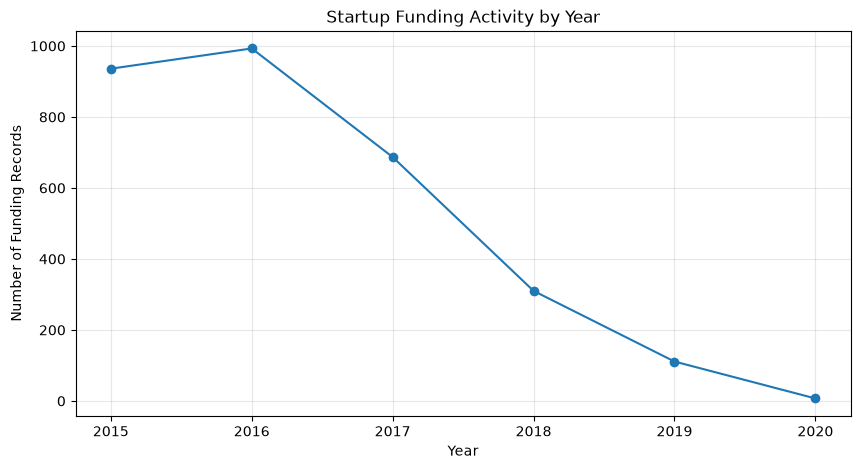

In [138]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    yearly_funding["funding_year"],
    yearly_funding["funding_records"],
    marker="o"
)

plt.title("Startup Funding Activity by Year")
plt.xlabel("Year")
plt.ylabel("Number of Funding Records")
plt.xticks(yearly_funding["funding_year"])
plt.grid(True, alpha=0.3)

plt.show()

In [139]:
## 2. Funding by Investment Type

investment_type_counts = (
    final_data["investment_type"]
    .value_counts()
    .reset_index()
)

investment_type_counts.columns = ["investment_type", "funding_records"]

investment_type_counts

,investment_type,funding_records
0,Seed,1398
1,Private Equity,1363
2,Seed / Angel,144
3,Debt,29
4,Series A,24
5,Series B,21
6,Series C,14
7,Series D,12
8,Pre-Series A,9
9,Venture,4


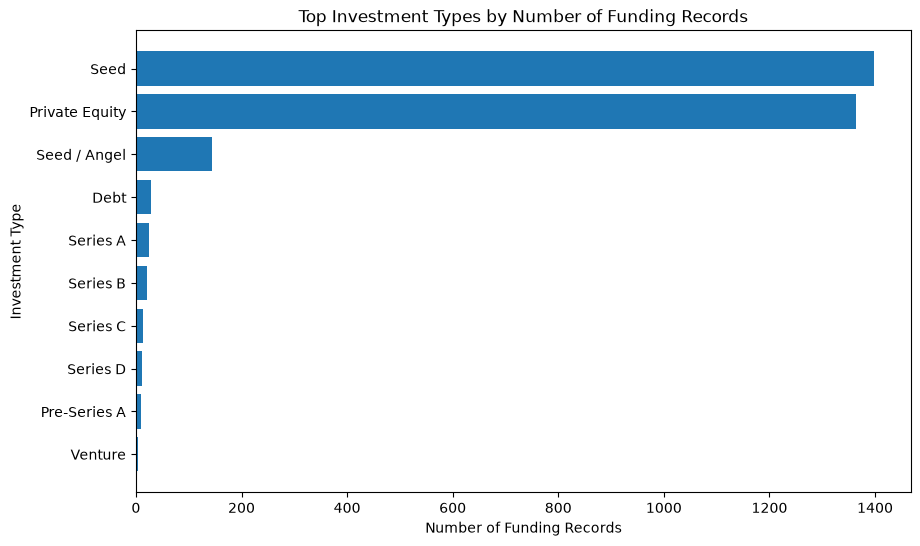

In [140]:
top_investment_types = investment_type_counts.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_investment_types["investment_type"][::-1],
    top_investment_types["funding_records"][::-1]
)

plt.title("Top Investment Types by Number of Funding Records")
plt.xlabel("Number of Funding Records")
plt.ylabel("Investment Type")

plt.show()

In [141]:
## 3. Funding Amount by Investment Type

funding_by_type = (
    final_data
    .dropna(subset=["funding_amount_usd"])
    .groupby("investment_type")
    .agg(
        funding_records=("Sr No", "count"),
        total_funding_usd=("funding_amount_usd", "sum"),
        average_funding_usd=("funding_amount_usd", "mean")
    )
    .sort_values("total_funding_usd", ascending=False)
    .reset_index()
)

funding_by_type

,investment_type,funding_records,total_funding_usd,average_funding_usd
0,Private Equity,1078,2.725057e+10,2.527882e+07
1,Series B,21,4.805196e+09,2.288188e+08
2,Series D,12,1.481799e+09,1.234832e+08
3,Series C,14,1.044718e+09,7.462274e+07
4,Other / Unspecified,3,1.019180e+09,3.397267e+08
5,Seed,752,8.301209e+08,1.103884e+06
6,Series G,1,2.310000e+08,2.310000e+08
7,Seed / Angel,112,2.261606e+08,2.019291e+06
8,Series A,22,2.032000e+08,9.236364e+06
9,Debt,28,1.851024e+08,6.610798e+06


In [142]:
top_funding_types = funding_by_type.head(10)

top_funding_types

,investment_type,funding_records,total_funding_usd,average_funding_usd
0,Private Equity,1078,2.725057e+10,2.527882e+07
1,Series B,21,4.805196e+09,2.288188e+08
2,Series D,12,1.481799e+09,1.234832e+08
3,Series C,14,1.044718e+09,7.462274e+07
4,Other / Unspecified,3,1.019180e+09,3.397267e+08
5,Seed,752,8.301209e+08,1.103884e+06
6,Series G,1,2.310000e+08,2.310000e+08
7,Seed / Angel,112,2.261606e+08,2.019291e+06
8,Series A,22,2.032000e+08,9.236364e+06
9,Debt,28,1.851024e+08,6.610798e+06


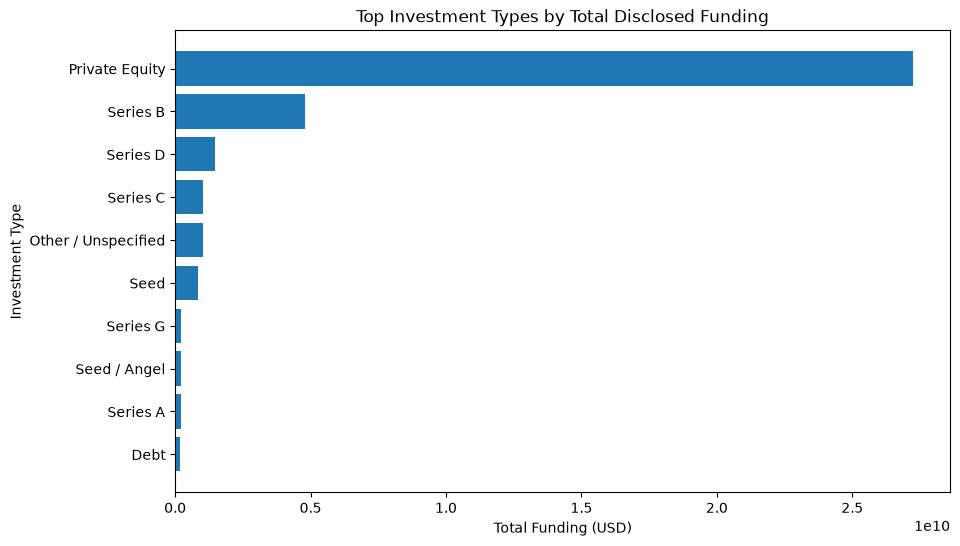

In [143]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_funding_types["investment_type"][::-1],
    top_funding_types["total_funding_usd"][::-1]
)

plt.title("Top Investment Types by Total Disclosed Funding")
plt.xlabel("Total Funding (USD)")
plt.ylabel("Investment Type")

plt.show()

In [144]:
top_funding_types = funding_by_type.head(10).copy()

top_funding_types["total_funding_billion"] = (
    top_funding_types["total_funding_usd"] / 1e9
)

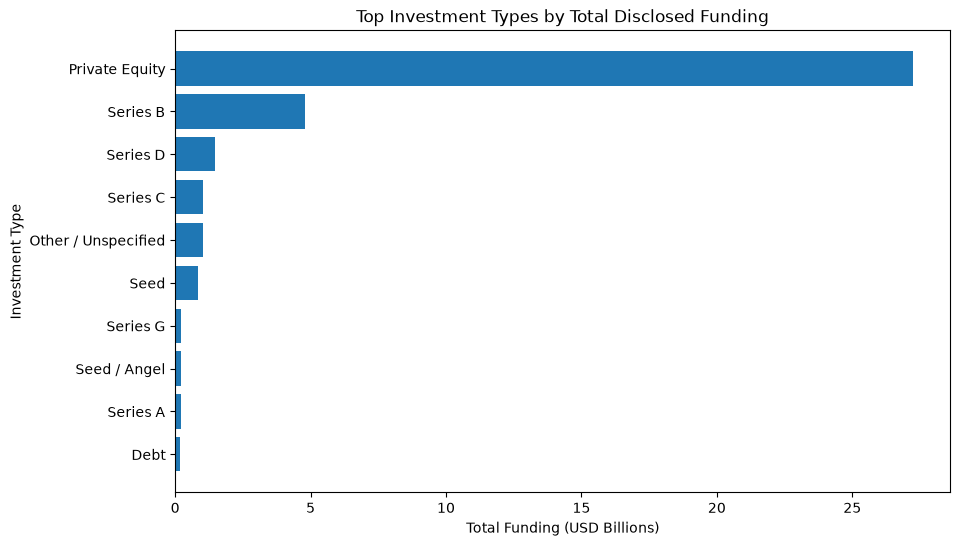

In [145]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_funding_types["investment_type"][::-1],
    top_funding_types["total_funding_billion"][::-1]
)

plt.title("Top Investment Types by Total Disclosed Funding")
plt.xlabel("Total Funding (USD Billions)")
plt.ylabel("Investment Type")

plt.show()

In [146]:
## 4. Funding Activity by Industry
industry_counts = (
    final_data["industry"]
    .value_counts()
    .reset_index()
)

industry_counts.columns = ["industry", "funding_records"]

industry_counts.head(15)

,industry,funding_records
0,consumer internet,942
1,technology,478
2,ecommerce,299
3,healthcare,71
4,finance,62
5,logistics,32
6,food & beverage,29
7,education,24
8,edtech,20
9,fintech,16


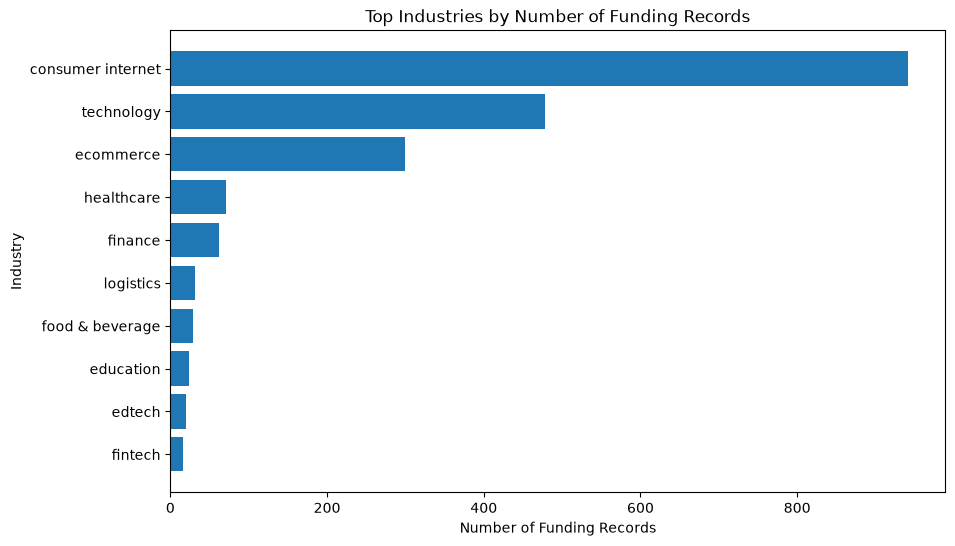

In [147]:
top_industries = industry_counts.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_industries["industry"][::-1],
    top_industries["funding_records"][::-1]
)

plt.title("Top Industries by Number of Funding Records")
plt.xlabel("Number of Funding Records")
plt.ylabel("Industry")

plt.show()

In [148]:
## 5. Funding Amount by Industry

funding_by_industry = (
    final_data
    .dropna(subset=["funding_amount_usd", "industry"])
    .groupby("industry")
    .agg(
        funding_records=("Sr No", "count"),
        total_funding_usd=("funding_amount_usd", "sum"),
        average_funding_usd=("funding_amount_usd", "mean")
    )
    .sort_values("total_funding_usd", ascending=False)
    .reset_index()
)

funding_by_industry.head(10)

,industry,funding_records,total_funding_usd,average_funding_usd
0,ecommerce,205,8.260736e+09,4.029627e+07
1,consumer internet,590,6.254084e+09,1.060014e+07
2,transportation,4,3.916632e+09,9.791581e+08
3,technology,310,2.229708e+09,7.192606e+06
4,finance,57,1.971438e+09,3.458663e+07
5,fintech,16,1.364911e+09,8.530695e+07
6,online marketplace,2,7.001430e+08,3.500715e+08
7,ecommerce & mcommerce platform,1,6.800000e+08,6.800000e+08
8,b2b,2,5.870000e+08,2.935000e+08
9,car aggregator & retail mobile app,1,5.000000e+08,5.000000e+08


In [149]:
top_industry_funding = funding_by_industry.head(10).copy()

top_industry_funding["total_funding_billion"] = (
    top_industry_funding["total_funding_usd"] / 1e9
)

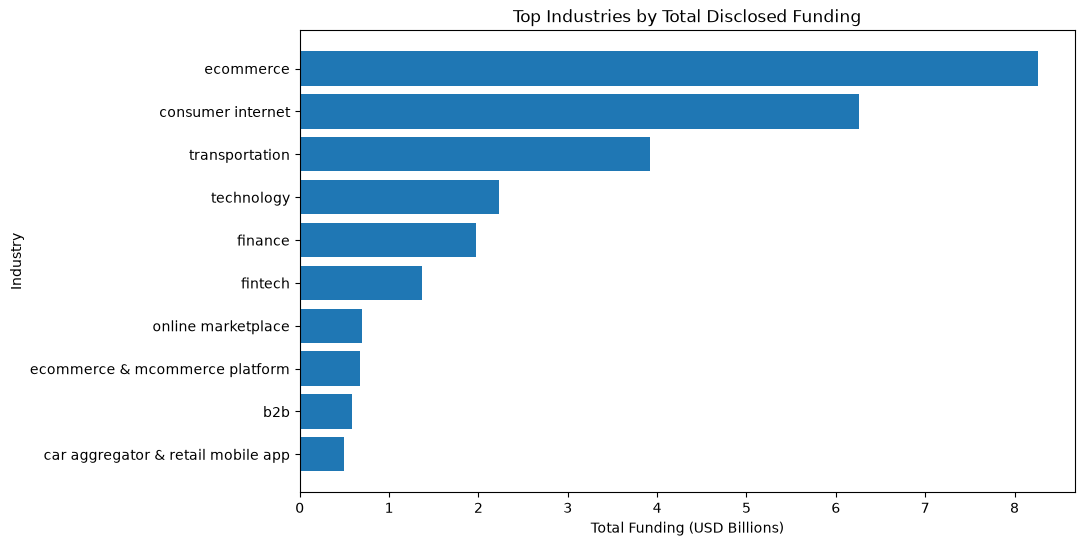

In [150]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_industry_funding["industry"][::-1],
    top_industry_funding["total_funding_billion"][::-1]
)

plt.title("Top Industries by Total Disclosed Funding")
plt.xlabel("Total Funding (USD Billions)")
plt.ylabel("Industry")

plt.show()

In [151]:
## 6. Funding Activity by City

city_counts = (
    final_data["city"]
    .value_counts()
    .reset_index()
)

city_counts.columns = ["city", "funding_records"]

city_counts.head(15)

,city,funding_records
0,Bengaluru,844
1,Mumbai,568
2,New Delhi,424
3,Gurugram,341
4,Pune,105
5,Hyderabad,99
6,Chennai,97
7,Noida,93
8,Ahmedabad,38
9,Delhi,34


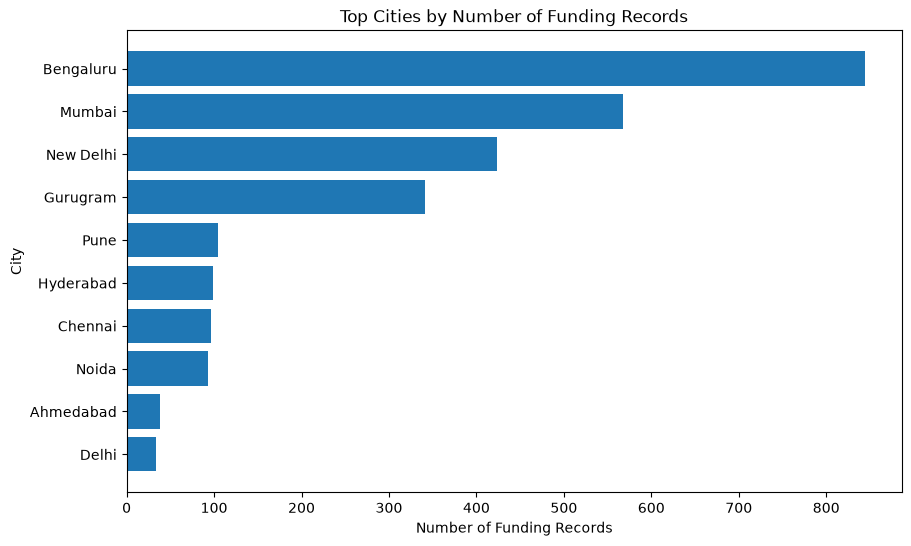

In [152]:
top_cities = city_counts.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_cities["city"][::-1],
    top_cities["funding_records"][::-1]
)

plt.title("Top Cities by Number of Funding Records")
plt.xlabel("Number of Funding Records")
plt.ylabel("City")

plt.show()

In [153]:
## 7. Funding Amount by City
funding_by_city = (
    final_data
    .dropna(subset=["funding_amount_usd", "city"])
    .groupby("city")
    .agg(
        funding_records=("Sr No", "count"),
        total_funding_usd=("funding_amount_usd", "sum"),
        average_funding_usd=("funding_amount_usd", "mean")
    )
    .sort_values("total_funding_usd", ascending=False)
    .reset_index()
)

funding_by_city.head(10)

,city,funding_records,total_funding_usd,average_funding_usd
0,Bengaluru,586,1.877471e+10,3.203875e+07
1,Mumbai,402,4.940535e+09,1.228989e+07
2,Gurugram,243,3.876914e+09,1.595438e+07
3,New Delhi,243,3.028417e+09,1.246262e+07
4,Noida,56,1.282864e+09,2.290829e+07
5,Chennai,75,7.187670e+08,9.583560e+06
6,Pune,71,6.330820e+08,8.916648e+06
7,Menlo Park,1,4.500000e+08,4.500000e+08
8,Hyderabad,72,4.010762e+08,5.570503e+06
9,California,1,3.000000e+08,3.000000e+08


In [154]:
top_city_funding = funding_by_city.head(10).copy()

top_city_funding["total_funding_billion"] = (
    top_city_funding["total_funding_usd"] / 1e9
)

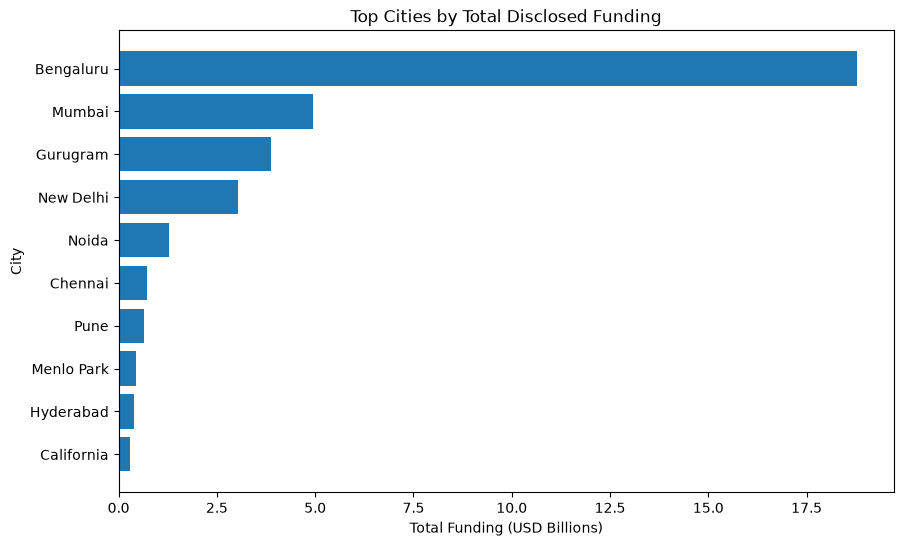

In [155]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_city_funding["city"][::-1],
    top_city_funding["total_funding_billion"][::-1]
)

plt.title("Top Cities by Total Disclosed Funding")
plt.xlabel("Total Funding (USD Billions)")
plt.ylabel("City")

plt.show()

In [156]:
## 8. Funding Amount Distribution

funding_stats = final_data["funding_amount_usd"].describe()

funding_stats

count    2.073000e+03
mean     1.840034e+07
std      1.211407e+08
min      1.600000e+04
25%      4.860000e+05
50%      1.750000e+06
75%      8.000000e+06
max      3.900000e+09
Name: funding_amount_usd, dtype: float64

In [157]:
final_data["funding_amount_usd"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.25    4.860000e+05
0.50    1.750000e+06
0.75    8.000000e+06
0.90    2.795980e+07
0.95    6.000000e+07
0.99    2.363200e+08
Name: funding_amount_usd, dtype: float64

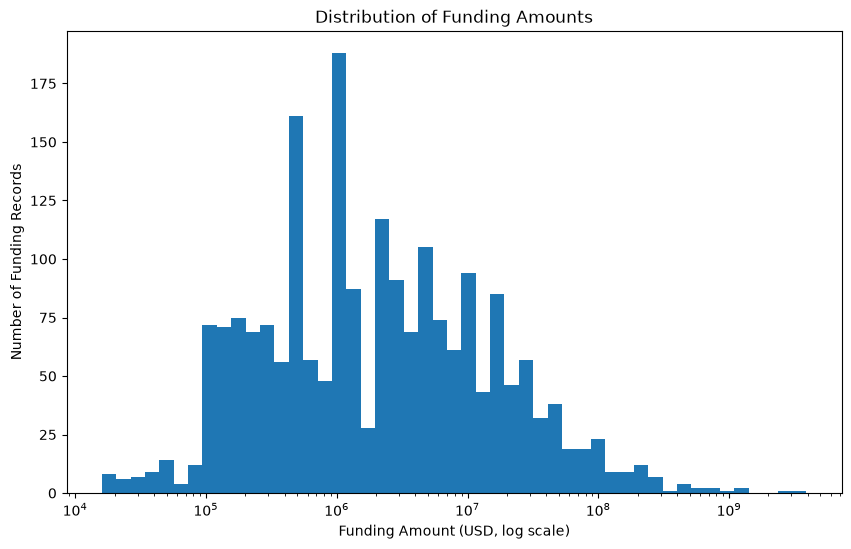

In [158]:
import numpy as np
import matplotlib.pyplot as plt

funding_values = final_data["funding_amount_usd"].dropna()

bins = np.logspace(
    np.log10(funding_values.min()),
    np.log10(funding_values.max()),
    50
)

plt.figure(figsize=(10, 6))

plt.hist(
    funding_values,
    bins=bins
)

plt.xscale("log")

plt.title("Distribution of Funding Amounts")
plt.xlabel("Funding Amount (USD, log scale)")
plt.ylabel("Number of Funding Records")

plt.show()

In [159]:
### Extreme Funding Events

top_funding_records = (
    final_data
    .dropna(subset=["funding_amount_usd"])
    .sort_values("funding_amount_usd", ascending=False)
)

top_funding_records[
    [
        "Startup Name",
        "funding_date",
        "industry",
        "investment_type",
        "funding_amount_usd"
    ]
].head(15)

,Startup Name,funding_date,industry,investment_type,funding_amount_usd
60,Rapido Bike Taxi,2019-08-27,transportation,Series B,3.900000e+09
651,Flipkart,2017-08-11,ecommerce,Private Equity,2.500000e+09
966,Flipkart,2017-03-21,ecommerce,Private Equity,1.400000e+09
830,Paytm,2017-05-18,ecommerce,Private Equity,1.400000e+09
31,Paytm,2019-11-25,fintech,Other / Unspecified,1.000000e+09
2648,Flipkart.com,2015-07-28,online marketplace,Private Equity,7.000000e+08
2459,Paytm,2015-09-29,ecommerce & mcommerce platform,Private Equity,6.800000e+08
188,True North,2018-08-30,finance,Private Equity,6.000000e+08
33,Udaan,2019-10-02,b2b,Series D,5.850000e+08
2470,Snapdeal,2015-08-01,ecommerce marketplace,Private Equity,5.000000e+08


In [160]:
## 9. Funding Amount Outliers

q1 = final_data["funding_amount_usd"].quantile(0.25)
q3 = final_data["funding_amount_usd"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 486000.0
Q3: 8000000.0
IQR: 7514000.0
Lower bound: -10785000.0
Upper bound: 19271000.0


In [161]:
outlier_count = (
    final_data["funding_amount_usd"] > upper_bound
).sum()

print("Number of upper outliers:", outlier_count)

Number of upper outliers: 285


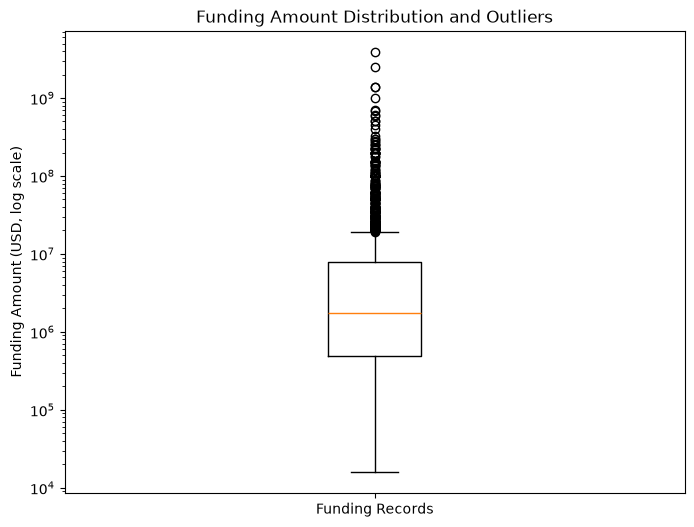

In [162]:
funding_values = final_data["funding_amount_usd"].dropna()

plt.figure(figsize=(8, 6))

plt.boxplot(funding_values)

plt.yscale("log")

plt.title("Funding Amount Distribution and Outliers")
plt.ylabel("Funding Amount (USD, log scale)")
plt.xticks([1], ["Funding Records"])

plt.show()

In [163]:
## 10. Top Startups by Total Disclosed Funding
startup_funding = (
    final_data
    .dropna(subset=["funding_amount_usd"])
    .groupby("Startup Name")
    .agg(
        funding_records=("Sr No", "count"),
        total_funding_usd=("funding_amount_usd", "sum"),
        average_funding_usd=("funding_amount_usd", "mean")
    )
    .sort_values("total_funding_usd", ascending=False)
    .reset_index()
)

startup_funding.head(15)

,Startup Name,funding_records,total_funding_usd,average_funding_usd
0,Flipkart,5,4.059700e+09,8.119400e+08
1,Rapido Bike Taxi,1,3.900000e+09,3.900000e+09
2,Paytm,5,3.148950e+09,6.297900e+08
3,Ola,4,9.845000e+08,2.461250e+08
4,Udaan,4,8.700000e+08,2.175000e+08
5,Flipkart.com,1,7.000000e+08,7.000000e+08
6,Snapdeal,2,7.000000e+08,3.500000e+08
7,Ola Cabs,7,6.697000e+08,9.567143e+07
8,True North,1,6.000000e+08,6.000000e+08
9,BigBasket,4,5.070000e+08,1.267500e+08


In [164]:
final_data[
    final_data["Startup Name"].str.lower().isin(
        ["flipkart", "flipkart.com", "ola", "ola cabs", "olacabs"]
    )
][
    [
        "Sr No",
        "Startup Name",
        "funding_date",
        "industry",
        "city",
        "investment_type",
        "funding_amount_usd"
    ]
].sort_values(["Startup Name", "funding_date"])

,Sr No,Startup Name,funding_date,industry,city,investment_type,funding_amount_usd
2689,2690,Flipkart,2015-06-04,ecommerce platform,Bengaluru,Private Equity,5.000000e+07
1032,1033,Flipkart,2017-02-20,ecommerce,Bengaluru,Private Equity,3.870000e+07
966,967,Flipkart,2017-03-21,ecommerce,Bengaluru,Private Equity,1.400000e+09
773,774,Flipkart,2017-06-26,ecommerce,Bengaluru,Private Equity,7.100000e+07
651,652,Flipkart,2017-08-11,ecommerce,Bengaluru,Private Equity,2.500000e+09
2648,2649,Flipkart.com,2015-07-28,online marketplace,Bengaluru,Private Equity,7.000000e+08
2244,2245,Ola,2015-11-18,car aggregator & retail mobile app,Bengaluru,Private Equity,5.000000e+08
924,925,Ola,2017-03-01,consumer internet,Bengaluru,Private Equity,3.300000e+08
791,792,Ola,2017-05-03,consumer internet,Bengaluru,Private Equity,1.045000e+08
748,749,Ola,2017-06-14,consumer internet,Bengaluru,Private Equity,5.000000e+07


In [165]:
startup_name_standardized = final_data["Startup Name"].copy()

startup_name_standardized = startup_name_standardized.replace({
    "Flipkart.com": "Flipkart",
    "Ola Cabs": "Ola",
    "Olacabs": "Ola"
})

final_data["startup_name_standardized"] = startup_name_standardized

In [166]:
final_data["startup_name_standardized"].value_counts().head(20)

startup_name_standardized
Ola              13
Swiggy            8
Paytm             7
Meesho            6
NoBroker          6
Nykaa             6
Flipkart          6
Medinfi           6
UrbanClap         6
Uniphore          5
Grofers           5
Moglix            5
Toppr             5
Capital Float     5
Jugnoo            5
Shuttl            4
Zomato            4
CarDekho          4
Rivigo            4
Healthians        4
Name: count, dtype: int64

In [167]:
print("Original unique:", final_data["Startup Name"].nunique())
print("Standardized unique:", final_data["startup_name_standardized"].nunique())


Original unique: 2459
Standardized unique: 2456


In [168]:
startup_funding = (
    final_data
    .dropna(subset=["funding_amount_usd"])
    .groupby("startup_name_standardized")
    .agg(
        funding_records=("Sr No", "count"),
        total_funding_usd=("funding_amount_usd", "sum"),
        average_funding_usd=("funding_amount_usd", "mean")
    )
    .sort_values("total_funding_usd", ascending=False)
    .reset_index()
)

startup_funding.head(15)

,startup_name_standardized,funding_records,total_funding_usd,average_funding_usd
0,Flipkart,6,4.759700e+09,7.932833e+08
1,Rapido Bike Taxi,1,3.900000e+09,3.900000e+09
2,Paytm,5,3.148950e+09,6.297900e+08
3,Ola,12,2.054200e+09,1.711833e+08
4,Udaan,4,8.700000e+08,2.175000e+08
5,Snapdeal,2,7.000000e+08,3.500000e+08
6,True North,1,6.000000e+08,6.000000e+08
7,BigBasket,4,5.070000e+08,1.267500e+08
8,GOQii,1,4.500000e+08,4.500000e+08
9,Zomato,4,4.350000e+08,1.087500e+08


In [169]:
final_data["startup_name_standardized"] = (
    final_data["startup_name_standardized"]
    .replace({
        "OYO Rooms": "Oyo Rooms"
    })
)

In [170]:
final_data[
    final_data["startup_name_standardized"].str.contains(
        "OYO|Oyo", case=False, na=False
    )
]["startup_name_standardized"].value_counts()

startup_name_standardized
Oyo Rooms    5
OyoRooms     2
FroyoFit     1
Oyo          1
OYOfit       1
Oyorooms     1
Name: count, dtype: int64

In [171]:
final_data["startup_name_standardized"] = (
    final_data["startup_name_standardized"]
    .replace({
        "OyoRooms": "Oyo Rooms",
        "Oyorooms": "Oyo Rooms"
    })
)

In [172]:
final_data[
    final_data["startup_name_standardized"].str.lower().isin(
        ["oyo rooms", "oyorooms", "oyo"]
    )
]["startup_name_standardized"].value_counts()

startup_name_standardized
Oyo Rooms    8
Oyo          1
Name: count, dtype: int64

In [173]:
startup_funding = (
    final_data
    .dropna(subset=["funding_amount_usd"])
    .groupby("startup_name_standardized")
    .agg(
        funding_records=("Sr No", "count"),
        total_funding_usd=("funding_amount_usd", "sum"),
        average_funding_usd=("funding_amount_usd", "mean")
    )
    .sort_values("total_funding_usd", ascending=False)
    .reset_index()
)

startup_funding.head(15)

,startup_name_standardized,funding_records,total_funding_usd,average_funding_usd
0,Flipkart,6,4.759700e+09,7.932833e+08
1,Rapido Bike Taxi,1,3.900000e+09,3.900000e+09
2,Paytm,5,3.148950e+09,6.297900e+08
3,Ola,12,2.054200e+09,1.711833e+08
4,Oyo Rooms,8,8.970000e+08,1.121250e+08
5,Udaan,4,8.700000e+08,2.175000e+08
6,Snapdeal,2,7.000000e+08,3.500000e+08
7,True North,1,6.000000e+08,6.000000e+08
8,BigBasket,4,5.070000e+08,1.267500e+08
9,GOQii,1,4.500000e+08,4.500000e+08


In [174]:
final_data[
    final_data["startup_name_standardized"] == "Rapido Bike Taxi"
][
    [
        "Sr No",
        "Startup Name",
        "funding_date",
        "industry",
        "city",
        "investors",
        "investment_type",
        "funding_amount_usd",
        "amount_is_lower_bound"
    ]
]

,Sr No,Startup Name,funding_date,industry,city,investors,investment_type,funding_amount_usd,amount_is_lower_bound
60,61,Rapido Bike Taxi,2019-08-27,transportation,Bengaluru,Westbridge Capital,Series B,3.900000e+09,False


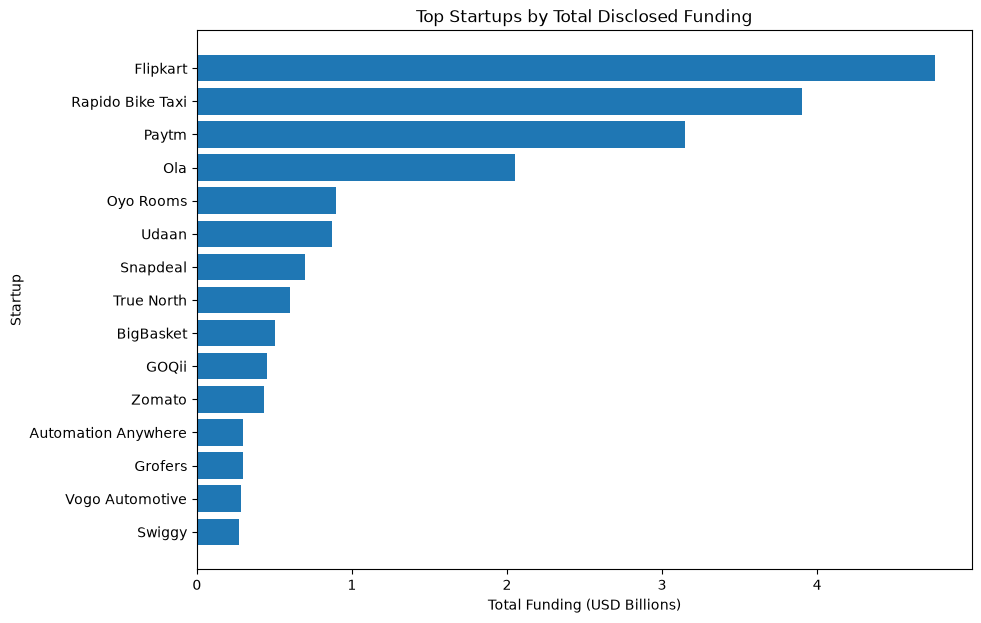

In [175]:
top_startups = startup_funding.head(15).copy()

top_startups["total_funding_billion"] = (
    top_startups["total_funding_usd"] / 1e9
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_startups["startup_name_standardized"][::-1],
    top_startups["total_funding_billion"][::-1]
)

plt.title("Top Startups by Total Disclosed Funding")
plt.xlabel("Total Funding (USD Billions)")
plt.ylabel("Startup")

plt.show()

In [176]:
print("Original unique startups:",
      final_data["Startup Name"].nunique())

print("Standardized unique startups:",
      final_data["startup_name_standardized"].nunique())

print("\nRemaining duplicate-name groups:")
print(
    final_data["startup_name_standardized"]
    .value_counts()
    .head(20)
)

Original unique startups: 2459
Standardized unique startups: 2453

Remaining duplicate-name groups:
startup_name_standardized
Ola              13
Oyo Rooms         8
Swiggy            8
Paytm             7
Meesho            6
NoBroker          6
Nykaa             6
Flipkart          6
Medinfi           6
UrbanClap         6
Uniphore          5
Grofers           5
Moglix            5
Toppr             5
Capital Float     5
Jugnoo            5
Shuttl            4
Zomato            4
CarDekho          4
Rivigo            4
Name: count, dtype: int64


In [177]:
print("Total funding records:", len(final_data))

print(
    "Records with disclosed funding:",
    final_data["funding_amount_usd"].notna().sum()
)

print(
    "Total disclosed funding: $",
    final_data["funding_amount_usd"].sum()
)

print(
    "Median disclosed funding: $",
    final_data["funding_amount_usd"].median()
)

print(
    "Mean disclosed funding: $",
    final_data["funding_amount_usd"].mean()
)

print(
    "Funding records above $100M:",
    (final_data["funding_amount_usd"] > 100_000_000).sum()
)

print(
    "Funding records above $500M:",
    (final_data["funding_amount_usd"] > 500_000_000).sum()
)

print(
    "Funding records above $1B:",
    (final_data["funding_amount_usd"] > 1_000_000_000).sum()
)

Total funding records: 3044
Records with disclosed funding: 2073
Total disclosed funding: $ 38143914864.22
Median disclosed funding: $ 1750000.0
Mean disclosed funding: $ 18400344.84525808
Funding records above $100M: 56
Funding records above $500M: 9
Funding records above $1B: 4


In [178]:
## 1. Funding Activity Changed Substantially Over Time

#The number of funding records varied considerably across the years. Funding activity was highest in 2016 with 993 records, followed by 2015 with 936 records and 2017 with 687 records. After 2017, the number of recorded funding events declined substantially, reaching 310 in 2018, 111 in 2019, and only 7 in 2020.

# This indicates that the dataset's recorded funding activity was heavily concentrated in the 2015–2017 period.


investment_counts = (
    final_data["investment_type"]
    .value_counts()
)

investment_share = (
    investment_counts
    .head(5)
    .div(len(final_data))
    .mul(100)
    .round(2)
)

investment_share

investment_type
Seed              45.93
Private Equity    44.78
Seed / Angel       4.73
Debt               0.95
Series A           0.79
Name: count, dtype: float64

In [179]:
## 2. Seed and Private Equity Funding Dominated the Dataset

# Seed funding and Private Equity were the two dominant investment types, accounting for 45.93% and 44.78% of all funding records, respectively. Together, they represented approximately 90.71% of the records in the dataset.

# Seed/Angel funding accounted for 4.73%, while Debt and Series A represented only 0.95% and 0.79%, respectively. This shows that the recorded funding activity was heavily concentrated in Seed and Private Equity categories.


investment_counts = final_data["investment_type"].value_counts()

investment_share = (
    investment_counts
    .head(5)
    .div(len(final_data))
    .mul(100)
    .round(2)
)

investment_share

investment_type
Seed              45.93
Private Equity    44.78
Seed / Angel       4.73
Debt               0.95
Series A           0.79
Name: count, dtype: float64

In [182]:
## 3. Startup Funding Activity Was Geographically Concentrated

#Bengaluru accounted for 29.47% of funding records with a recorded city, followed by Mumbai (19.83%), New Delhi (14.80%), and Gurugram (11.91%). Together, these four cities represented 76.01% of the records with available city information.

#This indicates a strong geographic concentration of recorded startup funding activity in a small number of major startup hubs.

city_counts = final_data["city"].value_counts()

city_share = (
    city_counts
    .head(10)
    .div(final_data["city"].notna().sum())
    .mul(100)
    .round(2)
)

city_share

city
Bengaluru    29.47
Mumbai       19.83
New Delhi    14.80
Gurugram     11.91
Pune          3.67
Hyderabad     3.46
Chennai       3.39
Noida         3.25
Ahmedabad     1.33
Delhi         1.19
Name: count, dtype: float64

In [184]:
mean_median_ratio = (
    final_data["funding_amount_usd"].mean()
    / final_data["funding_amount_usd"].median()
)

print("Mean / Median ratio:", round(mean_median_ratio, 2))

## 4. Funding Amounts Were Highly Right-Skewed

# The distribution of disclosed funding amounts was highly right-skewed. The median funding amount was $1.75 million, while the mean was approximately $18.40 million, making the mean about 10.51 times higher than the median.

# The interquartile range extended from $486,000 (Q1) to $8 million (Q3), while the maximum recorded funding amount was $3.9 billion. The IQR-based outlier analysis identified 285 observations above the upper outlier threshold.

# 
# This indicates that a relatively small number of very large funding events substantially influenced the overall distribution and mean funding amount.

Mean / Median ratio: 10.51


In [185]:
top_10_funding = startup_funding.head(10)["total_funding_usd"].sum()

total_disclosed_funding = final_data["funding_amount_usd"].sum()

top_10_share = (
    top_10_funding / total_disclosed_funding * 100
)

print("Top 10 total funding: $", top_10_funding)
print("Top 10 share of disclosed funding:", round(top_10_share, 2), "%")

Top 10 total funding: $ 17886850000.0
Top 10 share of disclosed funding: 46.89 %


In [186]:
top_5_funding = startup_funding.head(5)["total_funding_usd"].sum()

top_5_share = (
    top_5_funding / total_disclosed_funding * 100
)

print("Top 5 total funding: $", top_5_funding)
print("Top 5 share of disclosed funding:", round(top_5_share, 2), "%")

Top 5 total funding: $ 14759850000.0
Top 5 share of disclosed funding: 38.7 %


In [188]:
## 5. Funding Was Concentrated Among a Small Number of Startups

# The top 5 startups accounted for $14.76 billion, representing 38.70% of the total disclosed funding in the dataset. Expanding the group to the top 10 startups increased the share to $17.89 billion, or 46.89% of total disclosed funding.

 # This indicates that a relatively small number of highly funded startups accounted for a substantial proportion of the disclosed capital recorded in the dataset.

In [189]:
# Conclusion

#This analysis examined startup funding activity recorded between 2015 and 2020, covering 3,044 funding records. Funding amounts were available for 2,073 records, with total disclosed funding of approximately $38.14 billion.

#The EDA revealed several important patterns. Recorded funding activity was concentrated in the 2015–2017 period, while Seed and Private Equity represented the majority of funding records. Funding activity was also geographically concentrated, with Bengaluru, Mumbai, New Delhi, and Gurugram accounting for 76.01% of records with available city information.

#Funding amounts showed strong right-skewness, with a median of $1.75 million compared with a mean of $18.40 million. A relatively small number of exceptionally large funding events had a substantial influence on aggregate funding statistics. The concentration of capital was also evident at the startup level: the top five startups accounted for 38.70% of total disclosed funding, while the top ten accounted for 46.89%.

#Overall, the analysis shows that startup funding in this dataset was characterized by strong concentration across time, investment type, geography, and individual startups. Because a substantial proportion of funding amounts were undisclosed and the dataset covers a specific period, these findings describe patterns within the dataset rather than the complete startup funding ecosystem.

In [191]:
final_data.to_csv("../data/startup_funding_cleaned.csv", index=False)

In [192]:
pip install streamlit plotly

   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   -- ------------------------------------- 0.8/10.5 MB 5.3 MB/s eta 0:00:02
   ----- ---------------------------------- 1.6/10.5 MB 4.0 MB/s eta 0:00:03
   -------- ------------------------------- 2.4/10.5 MB 3.9 MB/s eta 0:00:03
   ------------ --------------------------- 3.4/10.5 MB 4.2 MB/s eta 0:00:02
   -------------- ------------------------- 3.9/10.5 MB 4.4 MB/s eta 0:00:02
   ----------------- ---------------------- 4.7/10.5 MB 3.9 MB/s eta 0:00:02
   --------------------- ------------------ 5.8/10.5 MB 4.1 MB/s eta 0:00:02
   ------------------------- -------------- 6.8/10.5 MB 4.1 MB/s eta 0:00:01
   -------------------------- ------------- 7.1/10.5 MB 3.8 MB/s eta 0:00:01
   ------------------------------ --------- 8.1/10.5 MB 3.9 MB/s eta 0:00:01
   ---------------------------------- ----- 9.2/10.5 MB 4.0 MB/s eta 0:00:01
   ------------------------------------- -- 10.0/10.5 MB 4.0 MB/s eta 0:00:01
   --

NameError: name 'streamlit' is not defined

: 